# Module 3: Programming Challenges

This notebook contains 12 programming challenges covering data loading, filtering, aggregation, visualization, data cleaning, and DataFrame merging using Python.

**Data Files:**
- `../data/students.csv` — 50 student records with demographics, GPA, and attendance data.
- `../data/sales.csv` — 100 sales transactions with products, categories, and revenue data.

Complete each problem in the provided code cell. Reference solutions are shown below each problem.

In [1]:
# Import commonly used libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load datasets into DataFrames
students = pd.read_csv('../data/students.csv')
sales = pd.read_csv('../data/sales.csv')

# Convert date column to datetime
sales['date'] = pd.to_datetime(sales['date'])

students.head()

,student_id,name,age,department,gpa,attendance_rate,credits_completed,scholarship
0,S001,Omar,22,AI,2.43,0.87,139,True
1,S002,Omar,19,AI,2.45,0.84,50,False
2,S003,Rania,21,Math,NaN,0.89,1,False
3,S004,Yasmin,23,Data Science,2.12,0.95,86,True
4,S005,Mariam,23,Physics,2.14,0.63,117,False


---
## Problem 1: Average GPA by Department

Write a program that loads `students.csv` and computes the **average GPA for each department**. Exclude any rows where GPA is missing. Display the result as a table sorted by department name.

**Expected Output:**

| department | avg_gpa |
|------------|---------|
| AI         | 2.51    |
| CS         | 2.47    |
| Data Science | 2.64  |
| Math       | 2.38    |
| Physics    | 2.55    |

(Results may vary slightly depending on missing data handling.)

In [2]:
# Write your solution here


In [3]:
# SOLUTION
# Drop rows with missing GPA, group by department, compute mean
avg_gpa_by_dept = (
    students.dropna(subset=['gpa'])
    .groupby('department')['gpa']
    .mean()
    .round(2)
    .sort_index()
    .reset_index()
)
avg_gpa_by_dept.columns = ['department', 'avg_gpa']
print(avg_gpa_by_dept.to_string(index=False))

  department  avg_gpa
          AI     2.85
          CS     2.78
Data Science     3.09
        Math     2.47
     Physics     2.35


---
## Problem 2: Total Revenue by Category

Write a program that loads `sales.csv` and computes the **total revenue** (quantity multiplied by unit_price) **for each product category**. Display the results sorted by total revenue in descending order.

**Expected Output:**

| category    | total_revenue |
|-------------|---------------|
| Electronics | 197,432.10    |
| Sports      | 152,110.50    |
| ...         | ...           |

Revenue = quantity * unit_price. Round to 2 decimal places.

In [4]:
# Write your solution here


In [5]:
# SOLUTION
# Create revenue column, group by category, sum
sales['revenue'] = sales['quantity'] * sales['unit_price']

revenue_by_cat = (
    sales.groupby('category')['revenue']
    .sum()
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)
revenue_by_cat.columns = ['category', 'total_revenue']
print(revenue_by_cat.to_string(index=False))

   category  total_revenue
      Books      120376.57
     Sports      118653.13
Electronics      105876.09
   Clothing       86963.72
       Food       82583.79


---
## Problem 3: Filter High-Performing Students

Write a program that filters `students.csv` to find all students who meet **both** of the following criteria:
- `attendance_rate` greater than 0.8
- `gpa` greater than 3.0

Display the `student_id`, `name`, `department`, `gpa`, and `attendance_rate` for each matching student.

**Expected Output:**

A filtered table showing only students who satisfy both conditions. The number of results will depend on the data.

In [6]:
# Write your solution here


In [7]:
# SOLUTION
# Boolean indexing with compound condition
high_performers = students[
    (students['attendance_rate'] > 0.8) & (students['gpa'] > 3.0)
][['student_id', 'name', 'department', 'gpa', 'attendance_rate']]

print(high_performers.to_string(index=False))
print(f"\n{len(high_performers)} students match both criteria.")

student_id    name   department  gpa  attendance_rate
      S013 Jessica           CS 3.18             0.90
      S015   Ahmed      Physics 3.05             0.88
      S016    Lina Data Science 3.72             0.87
      S018    Amal           CS 3.56             0.91
      S019  Khalid         Math 3.22             0.96
      S030   Ahmed Data Science 3.55             0.88
      S036   Layla Data Science 3.56             0.93
      S041    Saif Data Science 3.49             0.90
      S042     Ali Data Science 3.21             0.84
      S045   Karim Data Science 3.22             0.91
      S048    Lina Data Science 3.30             0.91

11 students match both criteria.


---
## Problem 4: Top 5 Most Expensive Products

Write a program that finds the **top 5 most expensive products** in `sales.csv` based on `unit_price`. Display the product name, category, and unit price. In case of ties in unit price, show all relevant rows.

**Expected Output:**

| product | category | unit_price |
|---------|----------|------------|
| ...     | ...      | 999.99     |

The five products with the highest `unit_price`.

In [8]:
# Write your solution here


In [9]:
# SOLUTION
# Drop duplicate products, sort by unit_price descending, take top 5
top_5_expensive = (
    sales[['product', 'category', 'unit_price']]
    .drop_duplicates()
    .sort_values('unit_price', ascending=False)
    .head(5)
    .reset_index(drop=True)
)
print(top_5_expensive.to_string(index=False))

                 product    category  unit_price
Linear Algebra Refresher       Books      980.88
         Camping Tent 2P      Sports      980.62
            Olive Oil 1L        Food      970.35
     Deep Learning Intro       Books      965.67
          Wireless Mouse Electronics      962.13


---
## Problem 5: Bar Chart — Average GPA by Department

Write a program that creates a **bar chart** showing the average GPA for each department. Use the same calculation from Problem 1. The chart must include:
- A meaningful title.
- Labelled x-axis (department) and y-axis (average GPA).
- Department names on the x-axis.

In [10]:
# Write your solution here


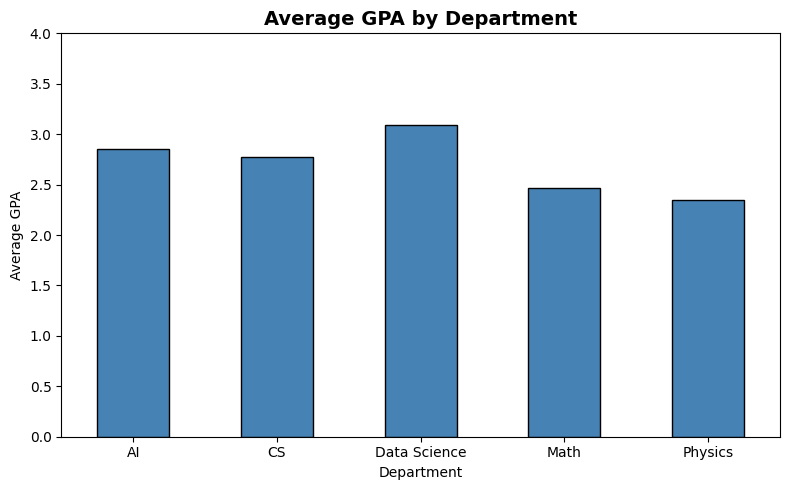

In [11]:
# SOLUTION
avg_gpa = students.dropna(subset=['gpa']).groupby('department')['gpa'].mean()

plt.figure(figsize=(8, 5))
avg_gpa.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average GPA by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Average GPA')
plt.xticks(rotation=0)
plt.ylim(0, 4.0)
plt.tight_layout()
plt.show()

---
## Problem 6: Histogram of Student Ages

Write a program that creates a **histogram** of student ages from `students.csv`. The chart must include:
- A meaningful title.
- Labelled axes.
- An appropriate number of bins (use 8 bins for uniformity).

In [12]:
# Write your solution here


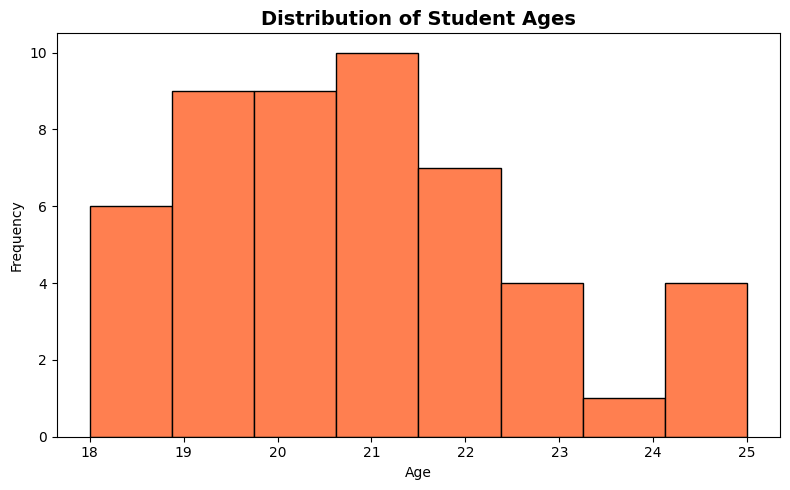

In [13]:
# SOLUTION
plt.figure(figsize=(8, 5))
plt.hist(students['age'], bins=8, color='coral', edgecolor='black')
plt.title('Distribution of Student Ages', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

---
## Problem 7: Scatter Plot — GPA vs Attendance Rate

Write a program that creates a **scatter plot** of `gpa` (y-axis) versus `attendance_rate` (x-axis) using `students.csv`. Exclude rows with missing GPA or attendance data. The chart must include:
- A meaningful title.
- Labelled axes.
- A distinct marker style.

In [14]:
# Write your solution here


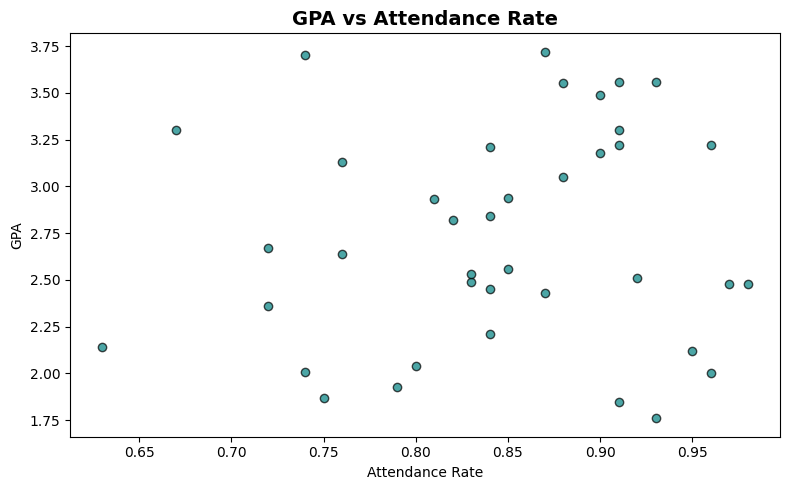

In [15]:
# SOLUTION
clean = students.dropna(subset=['gpa', 'attendance_rate'])

plt.figure(figsize=(8, 5))
plt.scatter(clean['attendance_rate'], clean['gpa'], alpha=0.7, c='teal', edgecolor='black')
plt.title('GPA vs Attendance Rate', fontsize=14, fontweight='bold')
plt.xlabel('Attendance Rate')
plt.ylabel('GPA')
plt.tight_layout()
plt.show()

---
## Problem 8: Line Plot — Monthly Sales Trends

Write a program that creates a **line plot** showing total sales revenue over time by month. Extract the month from the `date` column in `sales.csv` and group transactions by month. The chart must include:
- A meaningful title.
- Labelled axes.
- Monthly labels on the x-axis (e.g., Jan, Feb, ...).
- Revenue defined as `quantity * unit_price`.

In [16]:
# Write your solution here


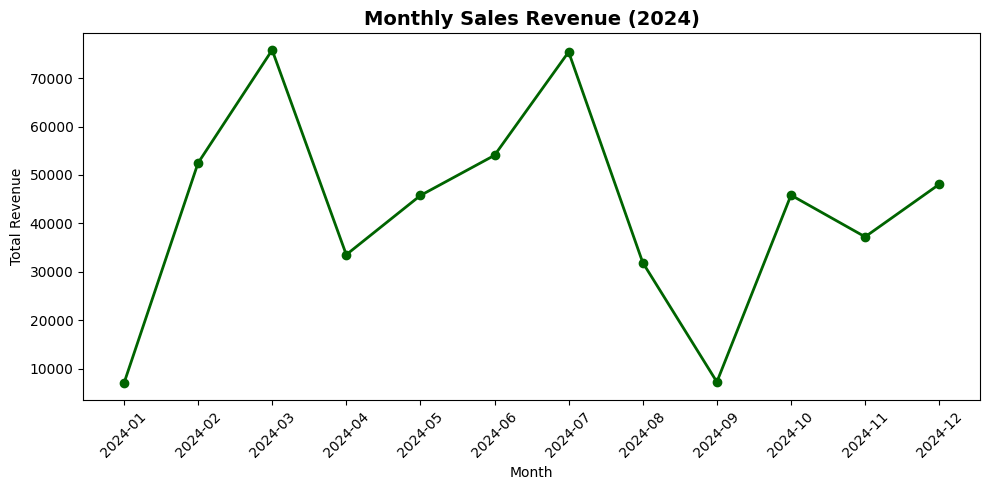

In [17]:
# SOLUTION
sales['revenue'] = sales['quantity'] * sales['unit_price']
sales['month'] = sales['date'].dt.to_period('M')

monthly_revenue = sales.groupby('month')['revenue'].sum()

plt.figure(figsize=(10, 5))
plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker='o',
    linestyle='-',
    color='darkgreen',
    linewidth=2
)
plt.title('Monthly Sales Revenue (2024)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## Problem 9: Handle Missing Data — Fill GPA with Department Average

Write a program that handles missing `gpa` values in `students.csv` by filling them with the **average GPA of the student's own department**. The program must:
1. Compute the mean GPA for each department (excluding missing values).
2. Fill each missing GPA with the corresponding department average.
3. Display the students who had their GPA imputed (show `student_id`, `name`, `department`, and the new `gpa` value).
4. Confirm that there are no remaining missing GPA values.

In [18]:
# Write your solution here


In [19]:
# SOLUTION
students_filled = students.copy()

# Compute department averages
dept_avg_gpa = students.groupby('department')['gpa'].mean()

# Identify rows with missing GPA
missing_gpa = students_filled['gpa'].isna()

# Fill missing GPA with department average
students_filled['gpa'] = students_filled['gpa'].fillna(
    students_filled['department'].map(dept_avg_gpa)
)

# Display the imputed rows
imputed = students_filled.loc[missing_gpa, ['student_id', 'name', 'department', 'gpa']]
print("Imputed GPA values:")
print(imputed.to_string(index=False))

# Confirm no remaining nulls
remaining_nulls = students_filled['gpa'].isna().sum()
print(f"\nRemaining missing GPA values: {remaining_nulls}")

Imputed GPA values:
student_id    name   department      gpa
      S003   Rania         Math 2.467143
      S007     Ali Data Science 3.089091
      S017    Ryan           AI 2.852857
      S021   Samir         Math 2.467143
      S023  Hassan           CS 2.775455
      S028 Jessica           CS 2.775455
      S039 Jessica      Physics 2.350000

Remaining missing GPA values: 0


---
## Problem 10: Mini Challenge — 4-Panel Dashboard

Write a program that creates a **single figure with four subplots** (2x2 grid) using the `students` dataset. Each subplot must show a different visualization:

1. **Top-left:** Bar chart of average GPA by department.
2. **Top-right:** Histogram of student ages.
3. **Bottom-left:** Scatter plot of GPA vs attendance_rate.
4. **Bottom-right:** Pie chart showing the proportion of students in each department.

The figure must have an overall title and appropriate axis labels for each subplot.

In [20]:
# Write your solution here


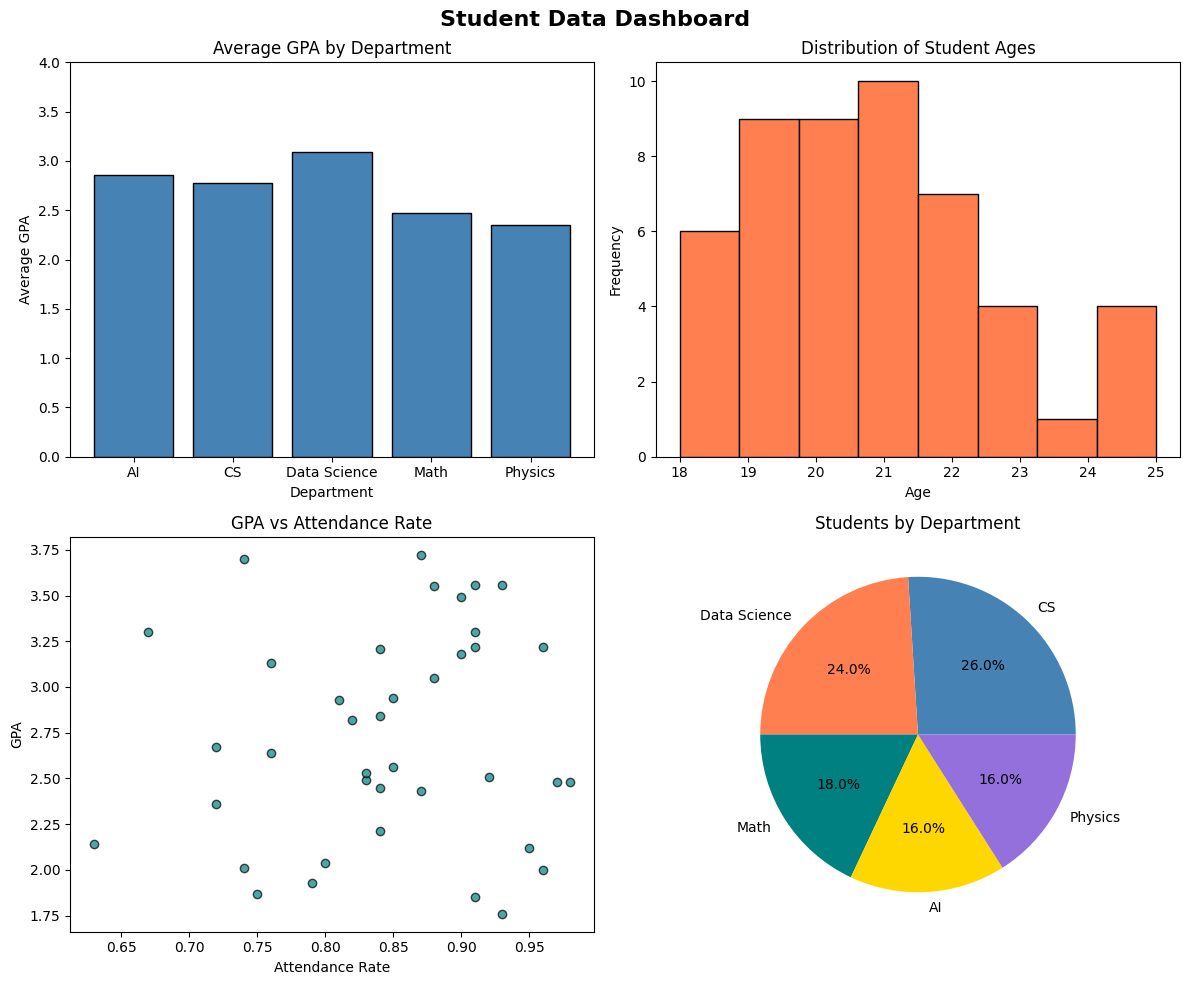

In [21]:
# SOLUTION
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Student Data Dashboard', fontsize=16, fontweight='bold')

# 1. Bar chart: average GPA by department
avg_gpa = students.dropna(subset=['gpa']).groupby('department')['gpa'].mean()
axes[0, 0].bar(avg_gpa.index, avg_gpa.values, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Average GPA by Department')
axes[0, 0].set_xlabel('Department')
axes[0, 0].set_ylabel('Average GPA')
axes[0, 0].set_ylim(0, 4.0)

# 2. Histogram: student ages
axes[0, 1].hist(students['age'], bins=8, color='coral', edgecolor='black')
axes[0, 1].set_title('Distribution of Student Ages')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Frequency')

# 3. Scatter plot: GPA vs attendance
clean_data = students.dropna(subset=['gpa', 'attendance_rate'])
axes[1, 0].scatter(clean_data['attendance_rate'], clean_data['gpa'],
                   alpha=0.7, c='teal', edgecolor='black')
axes[1, 0].set_title('GPA vs Attendance Rate')
axes[1, 0].set_xlabel('Attendance Rate')
axes[1, 0].set_ylabel('GPA')

# 4. Pie chart: students per department
dept_counts = students['department'].value_counts()
axes[1, 1].pie(dept_counts.values, labels=dept_counts.index, autopct='%1.1f%%',
               colors=['steelblue', 'coral', 'teal', 'gold', 'mediumpurple'])
axes[1, 1].set_title('Students by Department')

plt.tight_layout()
plt.show()

---
## Problem 11: Extract Month from Date and Count Transactions

Write a program that processes `sales.csv` to extract the month from each transaction's `date` column and counts how many transactions occurred in each month. The program must:

1. Ensure the `date` column is in datetime format.
2. Extract the month number from each date using the `.dt` accessor.
3. Count the number of transactions for each month.
4. Display the results sorted chronologically by month.

**Expected Output:**

| month | transaction_count |
|-------|-------------------|
| 1     | 8                 |
| 2     | 7                 |
| 3     | ...               |

The actual counts will depend on the data. All twelve months may not appear if no transactions occurred in some months.

In [22]:
# Write your solution here


In [23]:
# SOLUTION
# Ensure the date column is in datetime format
sales['date'] = pd.to_datetime(sales['date'])

# Extract the month number from each date
sales['month'] = sales['date'].dt.month

# Count the number of transactions per month
monthly_counts = (
    sales.groupby('month')
    .size()
    .reset_index(name='transaction_count')
    .sort_values('month')
)

print(monthly_counts.to_string(index=False))
print(f"\nTotal months with transactions: {len(monthly_counts)}")


 month  transaction_count
     1                  2
     2                  9
     3                  9
     4                 11
     5                  8
     6                 11
     7                 13
     8                  7
     9                  2
    10                 13
    11                  7
    12                  8

Total months with transactions: 12


---
## Problem 12: Merge Two Small DataFrames

Write a program that creates two small DataFrames from scratch and merges them using a common key column. The first DataFrame contains employee IDs, names, and department IDs. The second DataFrame contains department IDs and department names. Use an **inner join** on the `dept_id` column to produce a combined DataFrame showing each employee's name alongside their department name.

**DataFrame 1 (employees):**

| emp_id | name     | dept_id |
|--------|----------|---------|
| 101    | Alice    | 1       |
| 102    | Bob      | 2       |
| 103    | Charlie  | 1       |
| 104    | Diana    | 3       |

**DataFrame 2 (departments):**

| dept_id | dept_name       |
|---------|-----------------|
| 1       | Engineering     |
| 2       | Marketing       |
| 3       | Human Resources |

**Requirement:** Use `pd.merge()` with `on='dept_id'`. Print the merged DataFrame.

**Expected Output:**

| emp_id | name    | dept_id | dept_name       |
|--------|---------|---------|-----------------|
| 101    | Alice   | 1       | Engineering     |
| 102    | Bob     | 2       | Marketing       |
| 103    | Charlie | 1       | Engineering     |
| 104    | Diana   | 3       | Human Resources |

The merged DataFrame should contain all four employees, each with their department name resolved.

In [24]:
# Write your solution here


In [25]:
# SOLUTION
# Create the employees DataFrame
employees = pd.DataFrame({
    'emp_id': [101, 102, 103, 104],
    'name': ['Alice', 'Bob', 'Charlie', 'Diana'],
    'dept_id': [1, 2, 1, 3]
})

# Create the departments DataFrame
departments = pd.DataFrame({
    'dept_id': [1, 2, 3],
    'dept_name': ['Engineering', 'Marketing', 'Human Resources']
})

# Merge the two DataFrames on the common column dept_id
merged = pd.merge(employees, departments, on='dept_id')

print("Employees:")
print(employees.to_string(index=False))
print("\nDepartments:")
print(departments.to_string(index=False))
print("\nMerged Result:")
print(merged.to_string(index=False))


Employees:
 emp_id    name  dept_id
    101   Alice        1
    102     Bob        2
    103 Charlie        1
    104   Diana        3

Departments:
 dept_id       dept_name
       1     Engineering
       2       Marketing
       3 Human Resources

Merged Result:
 emp_id    name  dept_id       dept_name
    101   Alice        1     Engineering
    102     Bob        2       Marketing
    103 Charlie        1     Engineering
    104   Diana        3 Human Resources
